# Customer Churn Analysis
## Business Objective
This analysis aims to identify key factors driving customer churn for the telecom company and suggest actionable strategies to improve customer retention.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as mb

In [3]:
# Load dataset
df = pd.read_csv('C:/Users/DELL/Downloads/Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Clean and convert data types
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0").astype(float)


In [4]:
# Convert SeniorCitizen 0/1 to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].apply(lambda x: "Yes" if x == 1 else "No")


In [6]:
# Check for nulls and duplicates
print(df.isnull().sum().sum())      # No nulls
print(df['customerID'].duplicated().sum())  # No duplicates


0
0


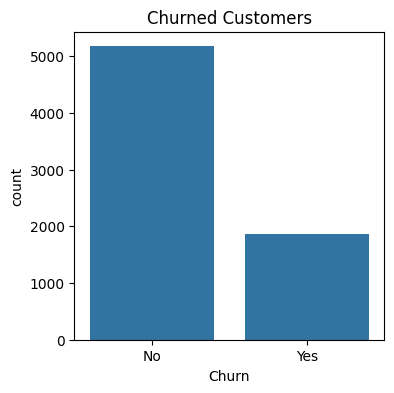

In [9]:

# --- CHURN COUNT ---
mb.figure(figsize=(4,4))
sb.countplot(x='Churn', data=df)
mb.title("Churned Customers")
mb.show()


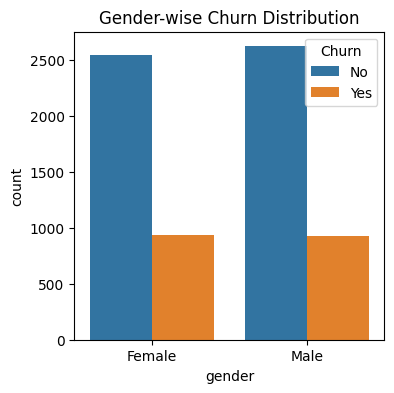

In [9]:
# --- GENDER VS CHURN ---
mb.figure(figsize=(4,4))
sb.countplot(x='gender', data=df, hue='Churn')
mb.title("Gender-wise Churn Distribution")
mb.show()

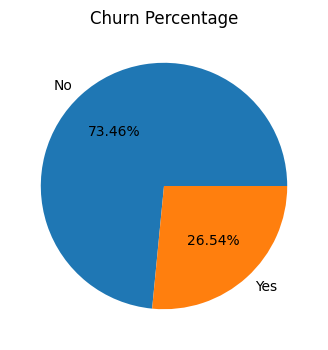

In [10]:
# --- PIE CHART OF CHURN ---
mb.figure(figsize=(4,4))
ab = df.groupby("Churn").agg({'Churn': 'count'})
mb.pie(ab['Churn'], labels=ab.index, autopct='%1.2f%%')
mb.title("Churn Percentage")
mb.show()

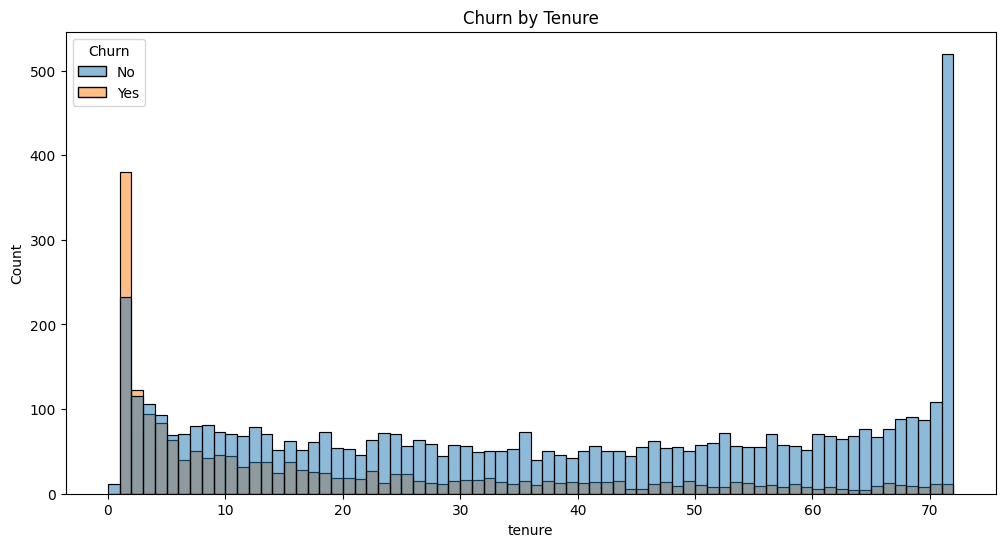

In [11]:
# --- TENURE DISTRIBUTION ---
mb.figure(figsize=(12,6))
sb.histplot(x="tenure", data=df, bins=72, hue="Churn")
mb.title("Churn by Tenure")
mb.show()


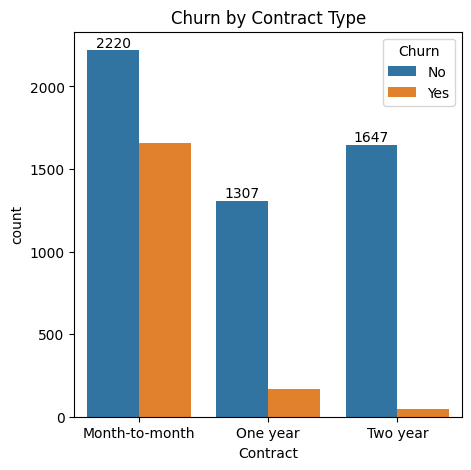

In [12]:
# --- CONTRACT TYPE VS CHURN ---
mb.figure(figsize=(5,5))
ss = sb.countplot(x='Contract', data=df, hue='Churn')
ss.bar_label(ss.containers[0])
mb.title("Churn by Contract Type")
mb.show()


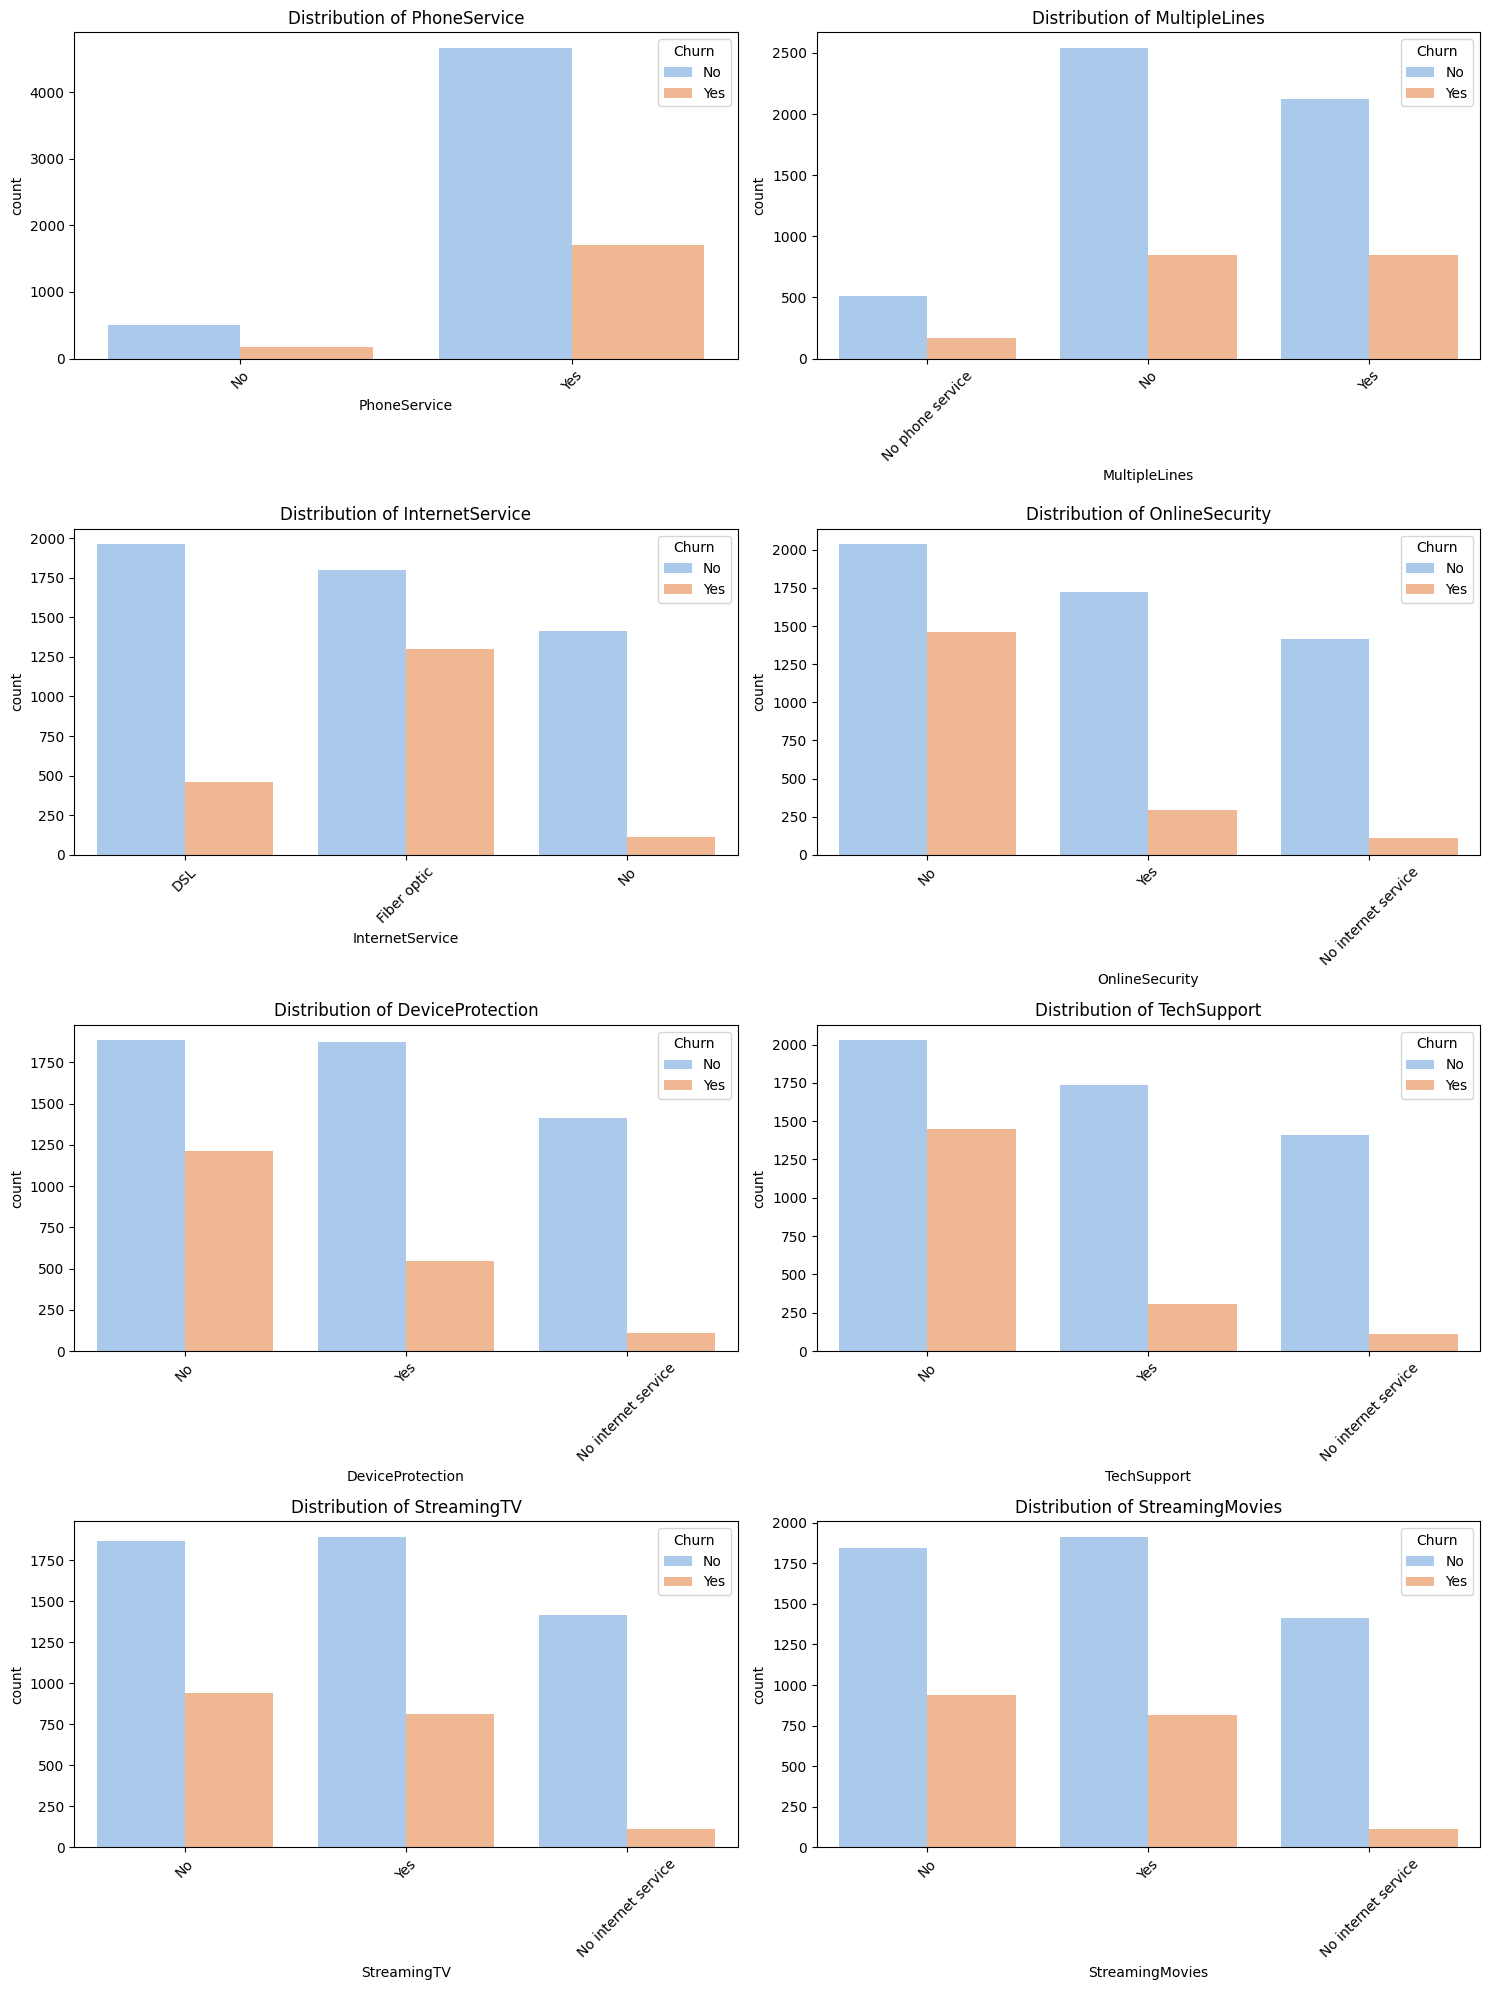

In [13]:
# --- MULTI-FEATURE CHURN ANALYSIS ---
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
           'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
fig, axes = mb.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    sb.countplot(data=df, x=col, ax=axes[i], hue='Churn', palette='pastel')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

mb.tight_layout()
mb.show()


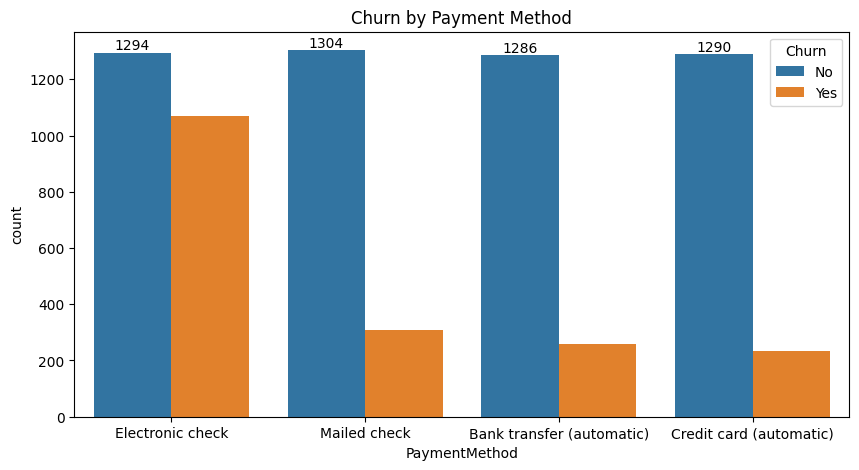

In [14]:
# --- PAYMENT METHOD VS CHURN ---
mb.figure(figsize=(10,5))
ss = sb.countplot(x='PaymentMethod', data=df, hue='Churn')
ss.bar_label(ss.containers[0])
mb.title("Churn by Payment Method")
mb.show()


## 6. Conclusion & Recommendations
- Customers with monthly contracts are more likely to churn.
- High monthly charges correlate with higher churn.
- Customers with paperless billing tend to churn more.

**Recommendations:**
- Provide loyalty incentives for long-term customers.
- Offer discounts or bundled services for monthly contract users.
- Promote paper billing to reduce churn tendency.